# Cycles in Party Platforms

In Ian Shapiro's open course, ["Power and Politics in Today’s World"](https://communications.yale.edu/2019-devane-lectures-power-and-politics-todays-world), he talks about a recurring trend in America which he refers to as "Good tactics, bad strategy". This trend occurs over the course of many election cycles, and consists of both parties shifting their platforms in the same direction, despite the lack of any underlying shift in reality that could explain this. The name Shapiro gives for this trend derives from his explanation about why it happens: the first party cares more than the other about the policy and thus shifts their proposed policy towards some ideal the party holds; the second party cares more than the first about winning the election, and thus follows the first party in an attempt to win over the moderates whom the first party is moving away from. This is "good tactics" for the second party because in the short term they are liklier to win elections through those moderates, but "bad strategy" because in the long term they abandon their soul (their ideal platform) and eventually their base of support. This behavior of the second party in a given election is also known as [triangulation](https://en.wikipedia.org/wiki/Triangulation_(politics)). Eventually, this conflict within the second party and associated election losses leads to a realignment where the second party assumes a platform much closer to its ideal. And, in the absence of any change or learning, the cycle may repeat.

This post seeks to provide an alternative explanation for such behavior of our political parties and contrast it with Shapiro's explanation. As you may guess from the fact that we're in a Jupyter Notebook, we'll be doing this by precisely defining each explanation and simulating the resulting behavior in a simplified setting. This setting consists of a sequence of elections between two candidates, and a one dimensional "policy space," where the platform of each candidate in each election can be represented as a point in this space. Each constituent also has a preferred policy that can be represented as a point in this space, and will never vote for the candidate whose platform is further from this preferred policy, as measured in this policy space. We'll start seeing how this works in the cell below.

If this is all sounding very abstract, just hold on because later in this notebook we'll look at an example issue in American politics where this platform cycling may be playing out: policing and the rights of racial minorities. 

0.2733333333333333 0.25666666666666665 0.24


Text(0, 0.5, 'Fraction of constituents')

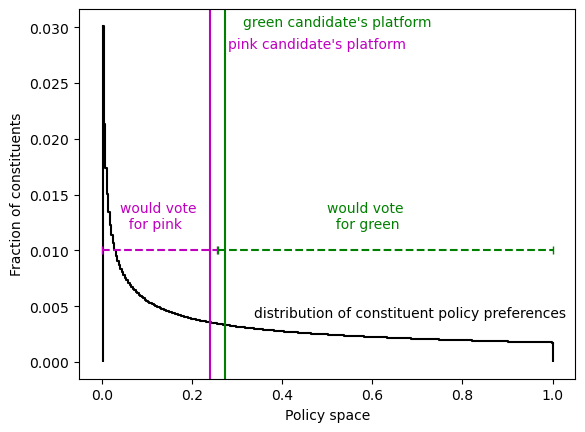

In [1]:
import numpy as np
from matplotlib import pyplot as plt

B = 300 #num bins; resolution of the policy space
C = 2 # num candidates
x = np.arange(1,B+1)/B # the policy space

# a power-law distribution of constituent policy preferrences
alpha = 0.5
voter_policy_dist = np.power(x,-alpha)
voter_policy_dist = voter_policy_dist/np.sum(voter_policy_dist) #normalize the distribution so it sums to 1

plt.step(x,voter_policy_dist,where='mid',color='k')
plt.text(x[B//3],voter_policy_dist[B//3]+0.001,'distribution of constituent policy preferences',color='k')
plt.vlines([x[0],x[-1]],[0,0],[voter_policy_dist[0],voter_policy_dist[-1]],color='k')

party_platforms = np.zeros((C,),dtype=int) #selected candidate platforms

#first candidate picks the median voter's preference:
party_platforms[0] = np.where(np.cumsum(voter_policy_dist)>=0.5)[0][0] 
plt.axvline(x[party_platforms[0]],color='g')
plt.text(x[party_platforms[0]]+0.04, np.max(voter_policy_dist), "green candidate's platform",color='g')

#second candidate picks a platform closer to the mode
party_platforms[1] = party_platforms[0] - 10
plt.axvline(x[party_platforms[1]],color='m')
plt.text(x[party_platforms[1]]+0.04, np.max(voter_policy_dist)-0.002, "pink candidate's platform",color='m')

plt.plot([0,x[int(np.mean(party_platforms))]-0.002],[0.01]*2,'m--|')
plt.text(0.04,0.012,'would vote\n  for pink',color='m')
plt.plot([x[int(np.mean(party_platforms))]+0.002,1],[0.01]*2,'g--|')
plt.text(0.5,0.012,'would vote\n  for green',color='g')

print(x[party_platforms[0]],x[int(np.mean(party_platforms))],x[party_platforms[1]])
plt.xlabel('Policy space')
plt.ylabel('Fraction of constituents')


We'll begin by defining the alternative explanation, which I'll call "Median-Mode Voter Competition". To understand this concept, we'll first have to understand the [Median Voter Theorem](https://en.wikipedia.org/wiki/Median_voter_theorem#:~:text=In%20political%20science%20and%20social,preferred%20by%20the%20median%20voter.). 

## The Median Voter Theorem
The linked Wikipedia page provides a nice overview, but essentially the theorem states that under certain conditions, candidates should adopt a platform that matches that of the "median voter". Some of these conditions do not apply if we assume there are only two candidates in the election, and the principle can be easily understood through the metaphor of ice cream:

Imagine you are an ice cream salesman and you're trying to decide where on a stretch of beach to park your truck in order to sell the most ice cream. The challenge is that your competitor, with her own truck, is making the same decision. Your prices and product are similar enough that you both assume that anyone on the beach who wants ice cream will walk to the nearest truck to buy it. So where should you park, assuming that you can park anywhere on the road that runs along the beach? Take a minute to think about it before reading on.

The answer is right in the center of the beach, where, to be precise, the center is where there are as many beachgoers (assuming each is equally likely to buy ice cream) to the right as to the left. To see this, imagine parking somewhere else, for example to the left of center. Then your competitor could park in the center, and all beachgoing ice-cream-eaters on her right (half of the total) would go to her, as well as some of the ones between the two of you. So more than half would go to your competitor and fewer than half would come to you.

Now look again at the graph above - instead of "policy space", the x-axis could equally well say "location on beach", the y-axis could say "fraction of beachgoers", the vertical lines could denote ice cream truck locations instead of candidate platforms, and the dashed lines could denote which sections of the beach would be served by each ice cream truck. So, although this analysis could be called the median ice-cream-buyer theorem, most people know it as the median voter theorem because of its applicability to elections.

The problem is that it is only so applicable to real-world elections: generally we don't observe candidates offering identical, centrist platforms - why not?

There are many, many potential reasons why we might see other behavior from candidates in real politics, such as party primaries or higher dimensional policy spaces. But today I'll focus on just two, which can account for the type of cycling I described earlier, starting with my "Median-Mode Voter Competition" explanation. 

## Median-Mode Voter Competition
One key assumption necessary for the Median Voter Theorem, which does not hold in reality, is that there is a fixed pool of voters: there is a fixed pool of *constituents*, any of whom can vote, but may or may not choose to do so in a given election, depending on their options, the candidates. Here, I assume that a constituent is *liklier* to vote when one candidate's platform is more similar to that constituent's ideal policy, and when the other candidate's platform is more different. This makes sense - if you perceive your options to be equally good or bad, you may not want to vote as much. Let's denote the Platforms of the two candidates $p_1$ and $p_2$ and the ideal Policy of a constituent $v$ as $p_v$, so that we can define the *Relevance* of an election to that constituent $v$ as $$\frac{\max_{c\in[1,2]}|p_c-p_v|}{\min_{c\in[1,2]}|p_c-p_v|}-1.$$
You can take a minute to see that this relevance will be zero when the two candidates' platforms are equally different from the constituent's ideal policy, and will tend towards $\infty$ when one candidate's platform (but not the other's) is very similar to the constituent's ideal policy. Now we can use the sigmoid function to convert this Relevance into a probability that a constituent will vote:

Text(0, 0.5, 'Probability that the constituent votes')

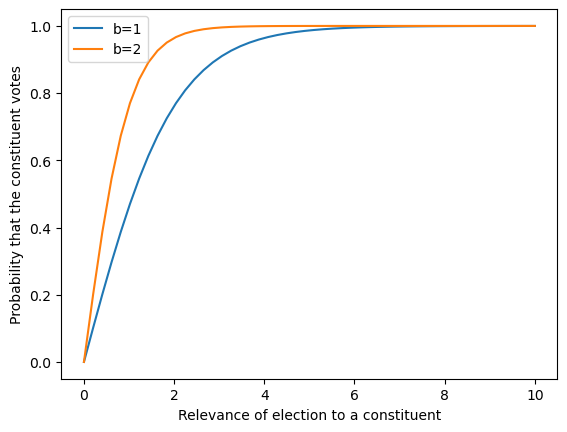

In [78]:
def sigmoid(x,b=5):
    '''
    The sigmoid function of the input x with parameter b, 
    scaled to output 0 at x=0 and tend towards 1 as x->infinity
    '''
    return (1/(1+np.exp(-b*x))-1/2)*2

#Illustration of the sigmoid function
y=np.linspace(0,10)
plt.plot(y,sigmoid(y,b=1),label='b=1')
plt.plot(y,sigmoid(y,b=2),label='b=2')
plt.legend()
plt.xlabel('Relevance of election to a constituent')
plt.ylabel('Probability that the constituent votes')

Note that the sigmoid function has a *parameter b*, which can be adjusted to modify how quickly the probability of a constituent voting changes as a function of the election's relevance to them. You can think of it as their *sensitivity* to relevance. We are now ready to pull this all together into a function each candidate can use to calculate how many votes he or she expects to win in an election:

In [79]:

def my_vote(cp_my,cp_other,vpd,f=sigmoid,f_args = {'b':5}):
    '''
    A function that a candidate can use to calculate how many votes
    he or she expects to win in an election
    Inputs:
        - cp_my (int): index (to vpd) of my Candidate Platform
        - cp_other (int): the Candidate Platform of the other
        - vpd (array): voter preferences distribution; sums to 1
        - f (function): the turnout function; 
            maps the ratio of difference in candidate platforms over difference from voter preference
            to the probability that voter votes
        - f_args: dict of kw args passed to f
    Outputs:
        - expected number of votes I expect to get with this platform
        (as a fraction of the electorate, or total number of constituents)
    '''
    B = vpd.size
    if cp_my == cp_other: # We want to avoid this case, since in this model, no one will vote
        return np.nan
    
    # the relevance of this election to constituents in each of the B bins
    relevance = np.abs(cp_other-np.arange(B))/(np.abs(cp_my-np.arange(B))+1e-10)-1
    
    # m is the fraction of the total electorate that is expected to vote in each bin:
    m = vpd*f(relevance,**f_args)

    min_to_me = 0 
    if cp_other<cp_my:
        min_to_me = (cp_my+cp_other)/2
    max_to_me = B-1
    if cp_other>cp_my:
        max_to_me = (cp_my+cp_other)/2
    vote_shares = np.zeros((B,)) #frac of m in each bin that go to me
    vote_shares[(min_to_me<np.arange(B))&(np.arange(B)<max_to_me)] = 1
    if type(min_to_me)==int:
        vote_shares[min_to_me]==1/2
    if type(max_to_me)==int:
        vote_shares[max_to_me]==1/2
    return vote_shares.dot(m)
  

We can now use this function to simulate a sequence of elections, where, each election, one party gets to modify its platform. We won't be explicitly modeling who wins the election, but we'll assume that the parties take turns modifying their platforms, picking the one that maximizes their expected share of the vote. This might make sense if the platform-modifying party always wins the election (as they are likelier to do) and then is restricted to supporting their incumbent for re-election in the next election. 

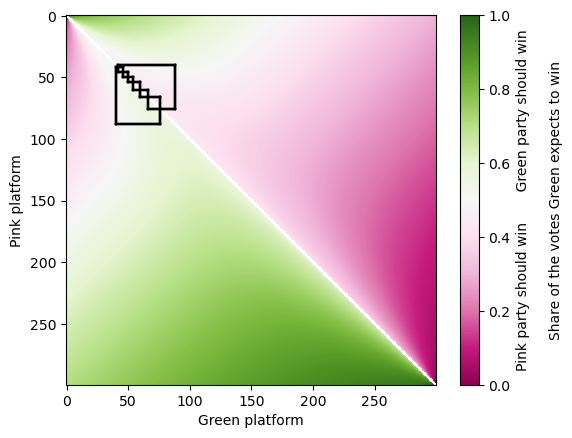

In [4]:
# for each pair of platforms, how  many votes the first party (Greens) expects to win
expected_votes = np.array([[my_vote(c1, c2, voter_policy_dist,f_args={'b':4}) for c1 in range(B)] for c2 in range(B)])
# for each pair of platforms, the share of the vote the first party (Greens) expects to win
expected_vote_share = expected_votes/(expected_votes+expected_votes.T)

plt.imshow(expected_vote_share,cmap='PiYG')
clb = plt.colorbar()
clb.set_label('Pink party should win       Green party should win\n\nShare of the votes Green expects to win')
plt.xlabel('Green platform')
plt.ylabel('Pink platform')
green_plats = [] #all platforms selected by the green party
pink_plats = []  #all platforms selected by the pink party

#The Green party goes first, and aligns with the median voter
green_plats.append(np.where(np.cumsum(voter_policy_dist)>=0.5)[0][0])

#simulate 100 elections
for i in range(100):
    # The Pink party picks the platform that minimizes the Greens' vote share
    new = np.nanargmin(expected_vote_share[:,green_plats[-1]])
    if i>20:
        plt.plot([green_plats[-1]]*2,[pink_plats[-1],new],'k')
    pink_plats.append(new)
    
    new = np.nanargmax(expected_vote_share[pink_plats[-1],:])
    if i>20:
        plt.plot([green_plats[-1],new],[pink_plats[-1]]*2,'k')
    green_plats.append(new)



Text(0, 0.5, 'Party Platforms')

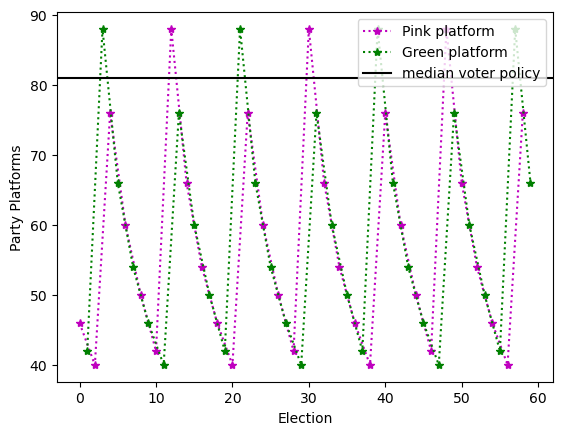

In [5]:
n = 30
plt.plot(2*np.arange(n),pink_plats[-n:],'m:*',label='Pink platform')
plt.plot(2*np.arange(n)+1,green_plats[-n:],'g:*',label='Green platform')
plt.axhline(np.where(np.cumsum(voter_policy_dist)>=0.5)[0][0],color='k',label='median voter policy')
plt.legend()
plt.xlabel('Election')
plt.ylabel('Party Platforms')

For this electorate, defined by their distribution of preferences and their sensitivity to the relevance of the election, $b$, it seems that the natural behavior of candidates results in a cycling of platforms similar to what we talked about at the start: a gradual shifting from election to election, followed by a sudden jump back. However, in this explanation, there is nothing different about the two parties! In fact, the parties effectively swap places every cycle! So clearly this explanation has nothing to do the two parties having different priorities - each is just a cold, calculating, election-winning machine. 

You might say that this is not very realistic either, but the point is that even with such simple motivations, this platform cycling behavior still happens. So what is going on?

We'll get into a more numerical approach at an answer shortly, but first, let's return to the ice cream metaphor, modifying it to match our new set of assumptions about constituents. First, your new goal as an ice-cream-truck-vendor is no longer selling the most ice cream, but selling more than your competitor, maybe in an attempt to win the People's Choice Award for best ice cream truck. Second, whether or not a beachgoer gets ice cream, and from whom, depends on how far away the trucks are from them: if they are both very far away, the beachgoer might forgo the frosty treat, for they would have too far to go; if they are both similarly close, the beachgoer might suffer from analysis paralysis at all the ice cream and likewise decide to pass as their thoughts shift to dialysis. A more realistic behavior might be that some beachgoers choose randomly between two similarly distant trucks, effectively benefiting neither (I'll return to this distinction later. And yes, benefiting is spelled that way. Thanks English). Finally, lets assume the beach has nice fine sand at the South end that gradually gives way to sharp rocks at the North, so there are more beachgoers crowded together on the sand, whereas only a few weirdos like me are scouring the sharp rocks for good skipping stones.

Suppose both trucks start next to the median beachgoer, who will be closer to the Southern end of the beach because of the nice sand there. With our old set of assumptions, neither truck could benefit by moving, but with our new assumptions, you can move your truck a little to the South and do better. Why? You've moved away from the median beachgoer, which means that now there are more beachgoers who would prefer to go to your opponents truck than yours! The thing is, many of those beachgoers won't actually get ice cream, since they're relatively far away (think of me, on my own at the Northern end, gleefully skipping rocks). Even though there are fewer people that you are the closer truck to, more of those people are relatively close to you, since you're on the Southern half of the beach, and so they are more likely to come get ice cream. If the conditions are right, this difference is big enough to make up for the beachgoers you abandoned who are now closer to the other truck.

But once you've moved your truck, your opponent realizes that they can do the same thing, and shortly take up a position even farther South. This continues until there are enough beachgoers back by the median that have been abandoned and no longer seek out ice cream that it makes sense for you to drive back over to the median. If the conditions are right, this makes sense to do because your opponent is so far South that there will be so many more beachgoers who are closer to you to make up for the fact that many of them (like me with my rocks or a beachgoer who's close to halfway between the trucks) are relatively far away from your truck. Then the only option for your opponent is to drive back over, close to the median, and the cycle can begin anew.

A couple times in this explanation, I made use of an assumption that "the conditions are right," but what exactly are these right conditions? In this model, the only two conditions are the locations of beachgoers (ideologies of voters) and the sensitivity parameter, $b$, which affects how likely they are to get ice cream (vote). So how can we find out what the right conditions for this cycling to occur are, and how might we tell if a particular electorate satisfies those conditions?

To answer the first question, we can simulate a sequence of elections for many different electorates using a *parameter sweep*. We'll look at power-law distributions of voters with exponent $\alpha$. Each distribution has its mode at 0 and its median less than 1/2, with lower $\alpha$ yielding uniform distribution of voters with a higher median. Let's simulate many different values of $\alpha$ and $b$ and see what happens!

In [80]:
# Helper functions for detecting a cycle in a sequence of elections

def circdiff(x):
    '''circular derivative of a vector: itself minus a shifted copy of itself'''
    return np.array(x)-np.roll(x,1)

        
def find_cycle(C,voter_policy_dist,turnout_fun,turnout_args={},ws=[0]*2,pols=[0]*2,pol_fun=np.abs):
    '''
    Inputs:
    C (int): number of candidates
    voter_policy_dist (array): voter preferences distribution; sums to 1
    turnout_fun (function): returns how likely a voter is to vote, as a funciton of the relevance of the election to them (sigmoid)
    turnout_args (dict): parameter value(s) for the turnout_fun (b)
    
    I don't use these until the next section
    ws (list): how much each party cares about how close their platform is to their ideal policy
    pols (list): the ideal policies of each party
    pol_fun (function): returns closeness of a platform to an ideal as a function of their difference
    
    Outputs:
    cycle (list): the new platforms in each election
    soft_period (float): on average, how many elections between parties starting to shift their platforms
    frac_up (float): the fraction of elections in which the new platform is a higher value (further from the mode) than the last
    frac2med (float): the fraction of elections in which the new platform is closer to the median than the last
    turnouts (list): the fraction of the electorate that votes in each election
    
    
    '''
    B = voter_policy_dist.size
    cycle = []    # the new platform in each election
    turnouts = [] # the turnout in each election
    med = np.where(np.cumsum(voter_policy_dist)>=0.5)[0][0] #median voter
    plats = list(range(med,med+C)) #"platforms" of each candidate, starting at the median voter
    for it in range(B):
        exp_turns = np.zeros((B,))    #the fraction of the electorate I expect to vote associated with adopting each policy
        vict_chances = np.zeros((B,)) #the fraction of those votes I expect to get associated with adopting each policy
        for plat in range(B):
            tmp_plats = np.array(plats)
            tmp_plats[0] = plat
            exp_votes = [my_vote(tmp_plats[i], tmp_plats[np.arange(C)!=i], voter_policy_dist,f=turnout_fun,f_args=turnout_args) for i in range(C)]
            vict_chances[plat] = exp_votes[0]/np.sum(exp_votes)
            exp_turns[plat] = np.sum(exp_votes)
            
        #candidate will select the platform that maximizes this
        platform_selection_criterion = vict_chances - ws[0]*pol_fun(pols[0]-np.arange(B))
        c1 = np.nanargmax(platform_selection_criterion) #c1 is the best policy
        plats = plats[1:]+[c1] #set the best policy and rotate the candidates
        ws = ws[1:]+[ws[0]]
        pols = pols[1:]+[pols[0]]
        
        if c1 in cycle: #if this platform was already proposed in a previous election, we've found a cycle
            # Trim off all elctions before the start of the cycle
            turnouts = turnouts[np.where(np.array(cycle)==c1)[0][0]:]
            cycle = cycle[np.where(np.array(cycle)==c1)[0][0]:]
            # Calculate properties of the cycle
            extrema = circdiff(np.sign(circdiff(cycle)))
            up_to_down = np.where(extrema==-2)[0]
            soft_period = len(cycle)/up_to_down.size
            down_to_up = np.where(extrema== 2)[0]
            # make sure an up-to-down extremum comes first
            if up_to_down[0]>down_to_up[0]:
                down_to_up = np.roll(down_to_up,-1)
            down_runs = np.mean(np.mod(down_to_up-up_to_down,len(cycle))-1)
            up_runs = np.mean(np.mod(up_to_down-np.roll(down_to_up,1),len(cycle))-1)
            if 2*up_to_down.size==len(cycle):
                frac_up = 1/2
                frac2med = 1/2
            else:
                frac_up = up_runs/(up_runs+down_runs)
                dist2med = np.abs(np.array(cycle)-med)
                frac2med = (np.sum(circdiff(dist2med)<0)-up_to_down.size)/(len(cycle)-2*up_to_down.size)
            return cycle, soft_period, frac_up, frac2med, turnouts
        cycle.append(c1)
        turnouts.append(exp_turns[c1])  

In [8]:
# run a parameter sweep

B = 300 # num bins in policy space
C = 2   # num parties
x = np.arange(1,B+1)/B

alphas = np.linspace(0.1,1.0,25) # exponent of the power-law distribution of voter preferences
bs = np.logspace(-1.5,2,25)      # slope parameter of the turnout function
cycles = np.nan*np.ones((alphas.size,bs.size,B))
turnouts = np.nan*np.ones((alphas.size,bs.size,B))
soft_periods = np.nan*np.ones((alphas.size,bs.size))
fracs_up = np.nan*np.ones((alphas.size,bs.size))
fracs2med = np.nan*np.ones((alphas.size,bs.size))
meds = np.zeros((alphas.size))

for ai, alpha in enumerate(alphas):
    voter_policy_dist = np.power(x,-alpha)
    voter_policy_dist/=np.sum(voter_policy_dist)
    meds[ai] = np.where(np.cumsum(voter_policy_dist)>=0.5)[0][0]
    for bi, b in enumerate(bs):
        cycle, soft_period, frac_up, frac2med, turnout = find_cycle(C,voter_policy_dist,sigmoid,turnout_args={'b':b})
        cycles[ai,bi,:len(cycle)] = cycle
        turnouts[ai,bi,:len(cycle)] = turnout
        soft_periods[ai,bi] = soft_period
        fracs_up[ai,bi] = frac_up
        fracs2med[ai,bi] = frac2med


In [9]:
# save the results
np.savez('results_C='+str(C)+'_B='+str(B),
        B = B, 
        C = C,
        alphas = alphas, 
        bs = bs, 
        cycles = cycles, 
        turnouts = turnouts, 
        soft_periods = soft_periods, 
        fracs_up = fracs_up, 
        fracs2med = fracs2med, 
        meds = meds, )

In [10]:
# reload old results
C=2
B=300
Dic = np.load('results_C='+str(C)+'_B='+str(B)+'.npz')
locals().update(Dic)

Now we can see how the presence (and length) of these cycles depends on our conditions. We're looking at the "soft period" of the cycle instead of the actual period because sometimes the parties go up and down through policy space but don't pick the exact same platform. A soft period of 2 corresponds to neither party changing its platform between elections (no cycle).

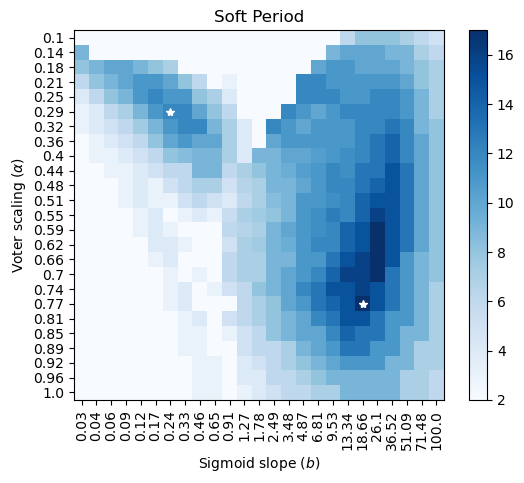

In [22]:
plt.imshow(soft_periods,cmap='Blues')
plt.colorbar()
plt.title('Soft Period')
plt.yticks(np.arange(alphas.size),alphas.round(2))
plt.ylabel(r'Voter scaling ($\alpha$)')
plt.xticks(np.arange(bs.size),bs.round(2),rotation=90)
plt.xlabel(r'Voter sensitivity ($b$)')

plt.plot([6,19],[5,18],'w*')

It seems like there are two main groups of conditions where longer cycles happen: more sensitive voters (high sigmoid slope $b$) and less sensitive with a flatter distribution of voter preferences (low $\alpha$). Why should this be? Nothing in our ice cream story suggested two groups of conditions.

To figure this out, we'd better look at some examples from each cluster (the white stars in the above plot) and see if our explanation holds up.

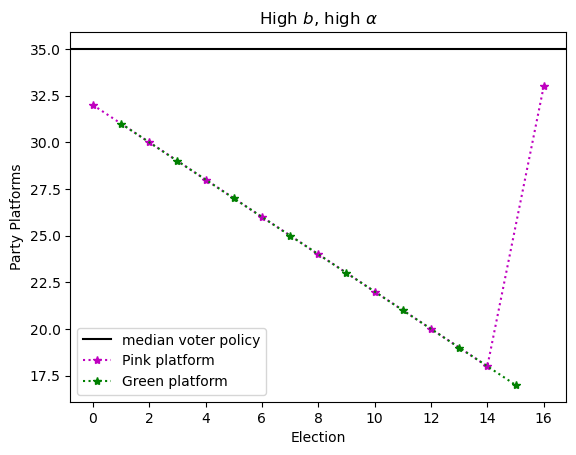

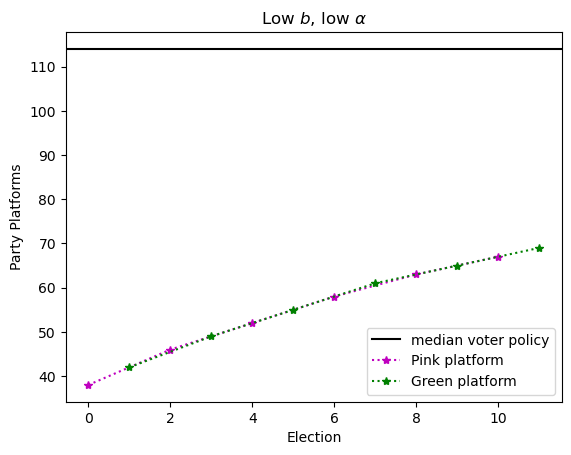

In [26]:
highleft = False
for ai,bi in ((18,19),(5,6)):
    plt.figure()
    cycle = cycles[ai,bi,:]
    cycle = cycle[~np.isnan(cycle)]
    pink_plats = cycle[0::2]
    green_plats = cycle[1::2]
    n = cycle.size
    plt.axhline(meds[ai],color='k',label='median voter policy')

    plt.plot(np.arange(0,n,2),pink_plats,'m:*',label='Pink platform')
    plt.plot(np.arange(1,n,2),green_plats,'g:*',label='Green platform')
    plt.legend()
    plt.xlabel('Election')
    plt.ylabel('Party Platforms')
    if highleft:
        plt.title(r'Low $b$, low $\alpha$')
        highleft = False
    else:
        plt.title(r'High $b$, high $\alpha$')
        highleft = True


It looks like relatively sensitive (high $b$) constituents yield a cycle like we were expecting, with parties taking small steps down towards the mode (at 0, like the Southern end with the nice fine sand), then taking a big jump back towards the median (the black line). But the low $b$, low $\alpha$ condition yields a different story completely! The small steps are going *away from the mode*, but never get even close to the median before the parties jump back towards the mode. Let's see if this consistently explains the two clusters by looking at the fraction of steps the parties take away from the mode:

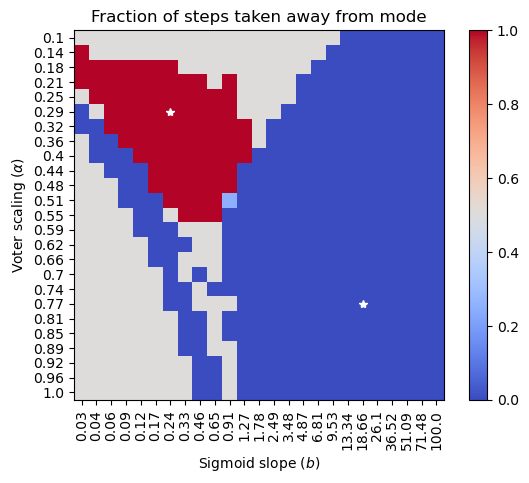

In [41]:
plt.imshow(fracs_up,cmap='coolwarm')
plt.colorbar()
plt.title('Fraction of steps taken away from mode')
plt.yticks(np.arange(alphas.size),alphas.round(2))
plt.ylabel(r'Voter scaling ($\alpha$)')
plt.xticks(np.arange(bs.size),bs.round(2),rotation=90)
plt.xlabel(r'Voter sensitivity ($b$)')
plt.plot([6,19],[5,18],'w*')

It seems like the two clusters indeed correspond to these two types of cycles. But why would we get the second type of cycle? Well, a lower $b$ means that people are less likely to vote for candidates whose platforms are far from their ideal, meaning that the each party should care more about appeasing the mode voter, relative to the median voter. In an extreme case where people only voted if a candidate proposed their preferred policy exactly, we would have the *Mode Voter Theorem*, with parties proposing platforms that corresponded to the mode voter's preference. In a less extreme case with voters who only vote if there is a proposed platform reasonably close to their preference, we can get a cycle where parties take small steps in the direction of the median since they are moving closer to more voters than they're moving away from. For this to be beneficial for both parties, the density of voters cannot decline too fast moving away from the mode, otherwise they would be abandoning too many voters. This would explain why a small $\alpha$ is also important for this type of cycle to occur. These small steps continue until the density of voters is low enough that parties do better jumping back towards the mode.

We can see that, as this story would suggest, this second type of cycle involves lower turnout.

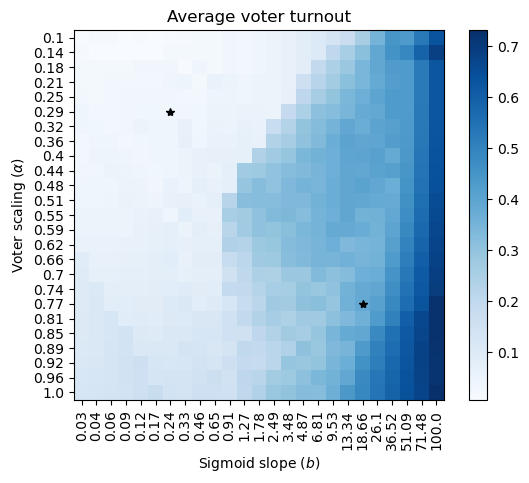

In [43]:
plt.imshow(np.nanmean(turnouts,axis=-1),cmap='Blues')
plt.colorbar()
plt.title('Average voter turnout')
plt.yticks(np.arange(alphas.size),alphas.round(2))
plt.ylabel(r'Voter scaling ($\alpha$)')
plt.xticks(np.arange(bs.size),bs.round(2),rotation=90)
plt.xlabel(r'Voter sensitivity ($b$)')
plt.plot([6,19],[5,18],'k*')

We can see this relationship more clearly by plotting the soft period against voter turnout across all conditions, using color to denote the two clusters:

Text(0, 0.5, 'Soft period')

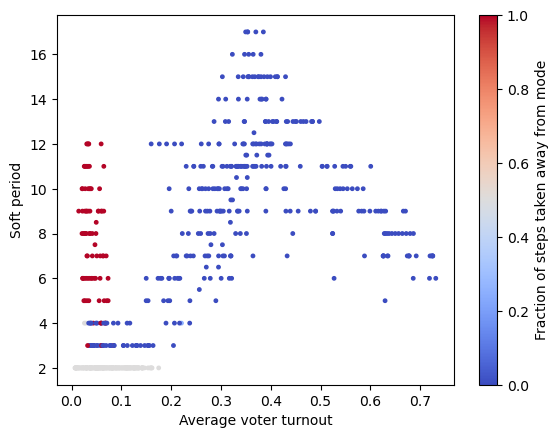

In [58]:
plt.scatter(np.ravel(np.nanmean(turnouts,axis=-1)),np.ravel(soft_periods),c=np.ravel(fracs_up),cmap='coolwarm',s=6)
cb = plt.colorbar()
cb.set_label('Fraction of steps taken away from mode')
plt.xlabel('Average voter turnout')
plt.ylabel('Soft period')

These plots also make clear what sort of turnout you need for each type of cycle to occur - the second type of cycle only occurs when turnout is less than 10%, whereas the first type can occur with normal levels of turnout. However, this doesn't necessarily mean that the first type is impossible with higher voter turnout. As I alluded to earlier in our ice cream metaphor, a voter faced with a choice between two platforms that are similarly different from her ideal might vote, but choose randomly between the two options. In this case, sensitivity would measure how different the two candidates have to be for people to vote *reliably in their interest* (not for people to vote at all). This distinction would allow for higher turnout statistics without leading to any other difference in terms of the observed cycles. This means that if we are trying to explain party cycles in the real world, we can't rule out either type of cycle on the basis of turnout alone — more on what we can do soon.

First, we should ask if any of these cycles (or non-cycles) are better or worse in terms of a democratic outcome. What could we mean by that? For one thing, we can ask what is the average platform that is in place, over the course of the cycle. This might be a reasonable thing to look at if the effects of platforms being in place over the years are additive (the median platform doesn't look much different anyways). As someone who tends to think that the median voter's preference represents a good place for comprimise, I would say that outcomes near the median are good; outcomes below the median are giving too much power to large interest groups, demographic majorities, or whatever you think underlies the concentration of preferences around the mode; and outcomes above the median give too much power to everyone else (but I'll admit you could make arguments against the median as a generically good outcome). 

So what average platforms do these cycles give rise to?

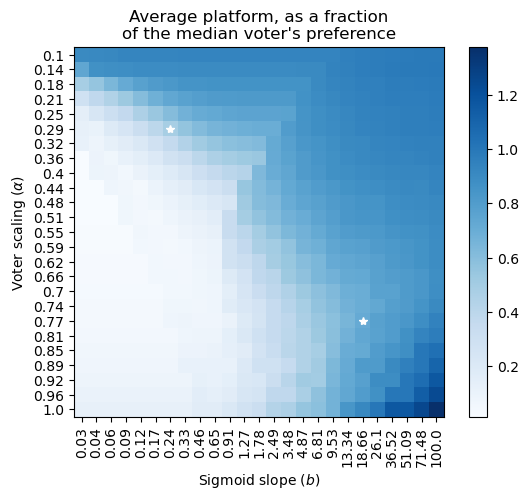

In [52]:
plt.imshow(np.nanmean(cycles,axis=-1)/np.tile(meds,(bs.size,1)).T,cmap='Blues')
plt.colorbar()
plt.title('Average platform, as a fraction\nof the median voter\'s preference')
plt.yticks(np.arange(alphas.size),alphas.round(2))
plt.ylabel(r'Voter scaling ($\alpha$)')
plt.xticks(np.arange(bs.size),bs.round(2),rotation=90)
plt.xlabel(r'Voter sensitivity ($b$)')
plt.plot([6,19],[5,18],'w*')

It seems like the more skewed distributions of less likely to vote voters (low-$b$, high-$\alpha$) give rise to average outcomes much closer to the mode than the median, and other electorates give rise to outcomes closer to the median. It's worth noting that the transition between these two outcomes does not correspond to the two types of cycles, although the two plots have some features in common. 

Next, we can ask how much variability there is from year to year. You could make a case for higher variability being better (more exploration of policies maybe), but I think most people would agree that, for a given *average* policy, more variation around that policy is bad. This is because changing policy presents a challenge for individuals and buisnesses who are trying to choose smart investments and plan for the future. All else equal, a known, stable policy is generally better than an unknown, unstable policy. This is especially true in this model, since one election can lead to a sudden shift in policy (the jumping point in the cycles). Because of this, I'll show the range of platforms proposed as a fraction of the mode-median separation:

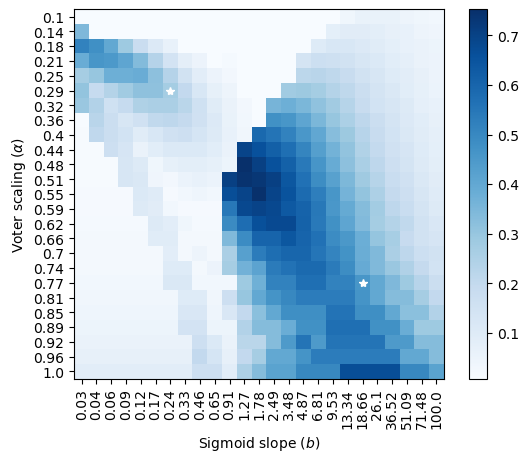

In [53]:
plt.imshow((np.nanmax(cycles,axis=-1)-np.nanmin(cycles,axis=-1))/np.tile(meds,(bs.size,1)).T,cmap='Blues')
plt.colorbar()
plt.title('')
plt.yticks(np.arange(alphas.size),alphas.round(2))
plt.ylabel(r'Voter scaling ($\alpha$)')
plt.xticks(np.arange(bs.size),bs.round(2),rotation=90)
plt.xlabel(r'Voter sensitivity ($b$)')
plt.plot([6,19],[5,18],'w*')

These sudden jumps in enacted policy can be really big, especially for the first type of cycle we looked at, with middling voter sensitivity.

This all paints a complicated picture, but one clear takeaway is this: under this model, when people are more *sensitive to the relevance of an election* in terms of the liklihood that they will vote in their own best interests, it leads to less extreme cycles with policies closer to that of the median voter.

Now it's time to shift gears and ask if this mechanism could be the cause of multi-election cycles in real world politics.

# Is the distribution of constituent preferences amenable to Median-Mode Voter Competition cycles?

To test if this mechanism could be the cause of cycles in the real world, we need some way of estimating the preferences of constituents. Voting records for each election only show who voted (but not for whom), meaning that results of multiple elections cannot easily be stitched together. However any one election shows preferences with very low resolution because of the small number of options, and only reflects the preferences of people who voted. [Cast Vote Records](https://www.nature.com/articles/s41597-024-04017-1?utm_source=chatgpt.com) could give us better resolution by revealing how many people voted for each combination of candidates/propositions, but I'm not going to look at that here, since it would likely still be too low resolution, and it would be more difficult to interpret results.

Instead we're going to look at survey data. Surveys ask lots of questions and often allow answers on a sliding scale, meaning we can assess preferences with higher resolution. additionally, the questions asked are simple, so we can easily interpret preferences in terms of those questions. Today, we're just going to look at one survey relating to an issue that may involve cycling, criminal justice, from around the time when the "War on Drugs" was getting started. You can access this survey [here](https://dataverse.unc.edu/dataset.xhtml?persistentId=hdl:1902.29/H-1935).

In [138]:
# use the rpy2 library to run R code from within our Python script 
# to load the survey results and convert them to a pandas DataFrame

from rpy2.robjects.packages import SignatureTranslatedAnonymousPackage
from rpy2.robjects.packages import importr
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from rpy2.robjects import pandas2ri
pandas2ri.activate()

string = """
read_spss <- function(x)
{
    library("foreign") #activates the library called foreign
    mydata <- read.spss(x, use.value.labels = TRUE,to.data.frame=TRUE)
    return(mydata)
}
"""

powerpack = SignatureTranslatedAnonymousPackage(string, "powerpack")
poll = '1935'
data = powerpack.read_spss("dataverse_files/harris_s"+poll+"_spss.por")

# convert to DataFrame
df = pd.DataFrame.from_dict({ key : np.asarray(data.rx2(key)) for key in data.names })
df[df.values<0] = np.nan #fill any non-answers with nan

Text(0, 0.5, "Fraction who didn't answer")

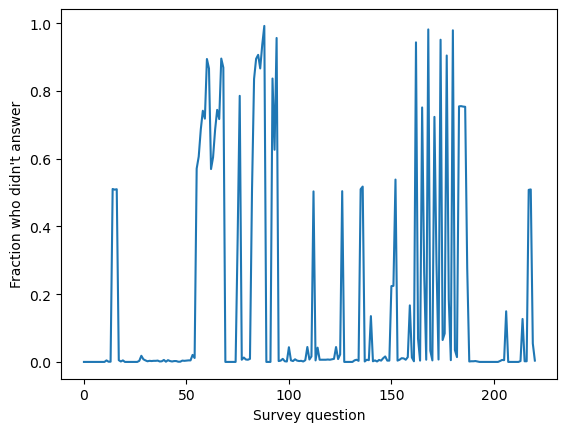

In [139]:
# One thing we'll need to be careful of is that some questions are 
# not answered by (or even asked to) every participant

plt.plot(np.mean(np.isnan(df.values),axis=0)) #nan means they didn't answer
plt.xlabel('Survey question')
plt.ylabel('Fraction who didn\'t answer')


In [140]:

polldf = pd.DataFrame(np.array([['1935','1561'],['Q','Q12'],[174,33],[1,2]]).T,
                      columns=['poll','prefix','conservative_response','pc'])
polldf = polldf.set_index('poll')
polldf.conservative_response = pd.to_numeric(polldf.conservative_response)
polldf.pc = pd.to_numeric(polldf.pc)

prefix = 'Q' #the codes for opinion questions start with 'Q'

# select the opinion questions that were answered by at least 95%
columns = [c for c in df.columns if df[c].unique()[~np.isnan(df[c].unique())].size==2 and prefix in c and np.mean(np.isnan(df[c].values))<0.05] 
# If the columns encode categorical answers (not binary),
# and we need to binarize them using "dummy columns."
dummy_cols = [c for c in df.columns if df[c].unique()[~np.isnan(df[c].unique())].size>2 and prefix in c and np.mean(np.isnan(df[c].values))<0.05]

crime_df = pd.get_dummies(df[columns+dummy_cols].astype(object),columns=dummy_cols).astype('float')
crime_df.head()

,Q1A_1,Q1A_2,Q1A_3,Q1A_4,Q1A_5,Q1A_6,Q1A_7,Q1A_8,Q1A_9,Q1A_10,...,Q34B_1.0,Q34B_2.0,Q34B_3.0,Q34B_4.0,Q34B_5.0,Q34B_6.0,Q34B_7.0,Q34B_8.0,Q34B_9.0,Q34B_10.0
0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We have a binary matrix of responses to questions, where the value in each cell denotes whether a particpant gave that answer to the corresponding question. 

Now, in order to use our Median-Mode Competition model, we need to extract a one-dimensional distribution of preferences from this data (ok, we could adapt our model but this is easier). How should we collapse this data down to one dimension? Principal Component Analysis is the standard choice, because it picks the one dimensional projection of the data that explains most of its variance. 

In [151]:
from scipy.sparse.linalg import svds
np.random.seed(1)
def pca(A, comp = 1):
    '''
    Inputs:
        A (np array): the matrix we want to reduce
        comp: how many dimensions we want to reduce to (1 today)
    Returns:
        The reduced matrix
        The matrix used to transform the data axes (question-responses) into the reduced axes
    '''
    #Subtract the mean and replace missing values with 0
    Ap = A-np.nanmean(A,axis=0)
    Ap[np.isnan(Ap)] = 0
    
    #apply SVD to get orthogonal axes that explain the most variance
    _, _, VT = svds(Ap,k=comp)
    
    return (Ap)@VT.T,VT

In [152]:
proj,weights = pca(crime_df.values)

Now each participant gets a single number representing their responses to this survey (which we are supposing reflects their policy preferences). We can look at which responses contribute the most to this number:

Most positive effect:  Q16C_4_1.0
Most negative effect:  Q16C_12_3.0


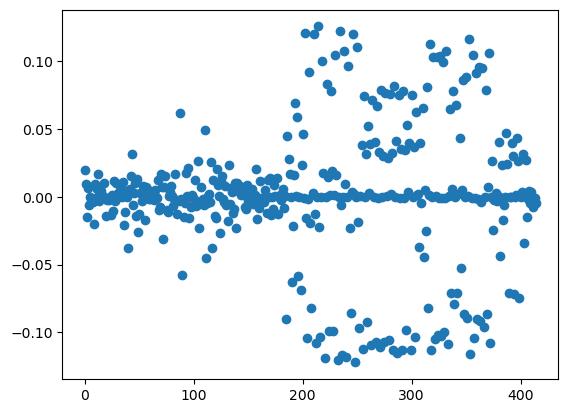

In [153]:
plt.plot(weights.T,'o')
print('Most positive effect: ',crime_df.columns[np.argmax(weights)])
print('Most negative effect: ',crime_df.columns[np.argmin(weights)])


Let's take a look at the actual survey:
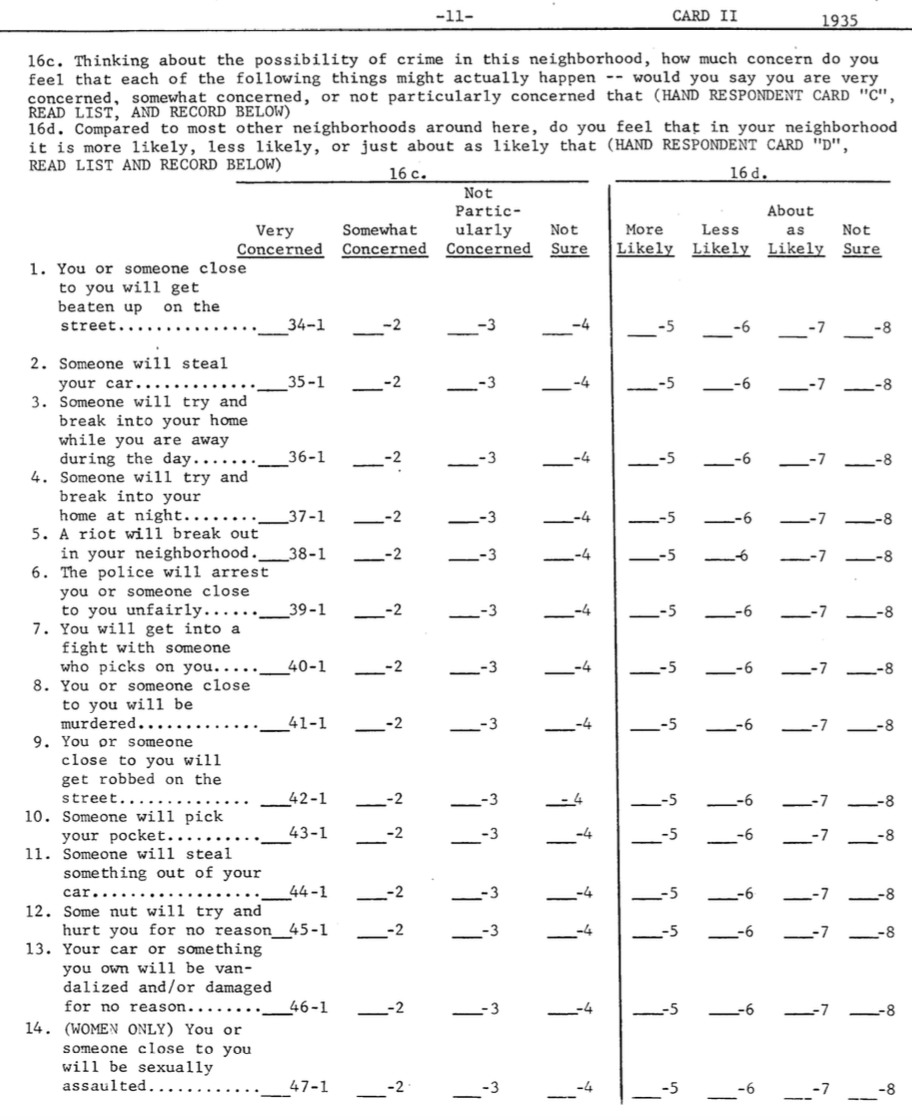

Q16C is asking participants how much concern they have that a bunch of horrible things will happen to themselves or someone else. A '3' denotes 'not particularly concerned' and a '1' denotes 'very concerned'. So we can understand the projection PCA came up with as encoding *how afraid of crime* the participant is. Why did PCA pull this dimension out? Because it was the most useful in explaining the variance of the whole dataset.

So now the moment of truth: what does the distribution of particpants look like, in terms of how afraid they are?

Text(0, 0.5, 'Fraction of participants')

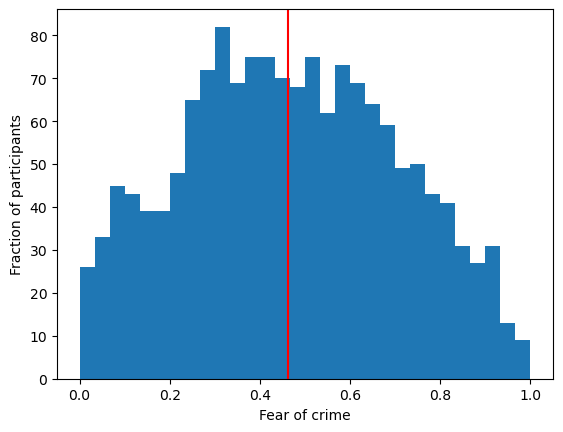

In [163]:
norm_proj = (proj-np.min(proj))/(np.max(proj)-np.min(proj))
med = np.median(norm_proj)
plt.hist(norm_proj,bins=30)
plt.axvline(med,c='r')
plt.xlabel('Fear of crime')
plt.ylabel('Fraction of participants')

The distribution does look a little skewed, which is necessary for Median-Mode competition to work (so that the median and mode aren't too close together). But is this really enough to generate cycles? Let's find out by running our model from before, using this data as the distribution of preferences:

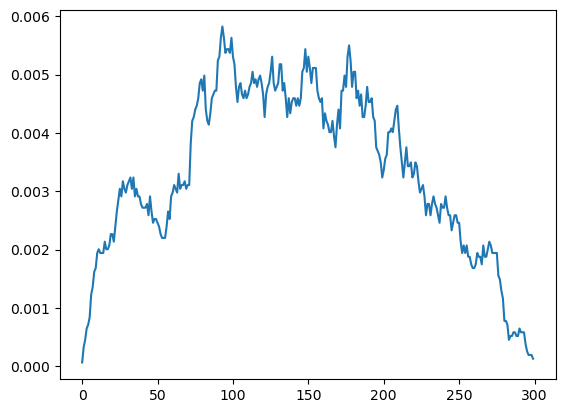

In [159]:
C = 2   # num parties
B = 300  # num bins in policy space
win_len = 10 #length of the sliding window used for smoothing
voter_policy_dist,_ = np.histogram(norm_proj,bins=B-win_len+1)
voter_policy_dist = np.convolve(voter_policy_dist,[1]*win_len,mode='full') #I'm smoothing it out because, at 300 bins, there's not enough data to get a smooth curve
voter_policy_dist = voter_policy_dist/np.sum(voter_policy_dist) #normalize so the distribution sums to 1

plt.plot(voter_policy_dist)

In [156]:
bs = np.logspace(-1.5,2,25)      # slope parameter of the turnout function
cycles = np.nan*np.ones((bs.size,B))
turnouts = np.nan*np.ones((bs.size,B))
soft_periods = np.nan*np.ones((bs.size))
fracs_up = np.nan*np.ones((bs.size))
fracs2med = np.nan*np.ones((bs.size))



for bi, b in enumerate(bs):
    cycle, soft_period, frac_up, frac2med, turnout = find_cycle(C,voter_policy_dist,sigmoid,turnout_args={'b':b})
    cycles[bi,:len(cycle)] = cycle
    turnouts[bi,:len(cycle)] = turnout
    soft_periods[bi] = soft_period
    fracs_up[bi] = frac_up
    fracs2med[bi] = frac2med

Text(0, 0.5, 'Soft period')

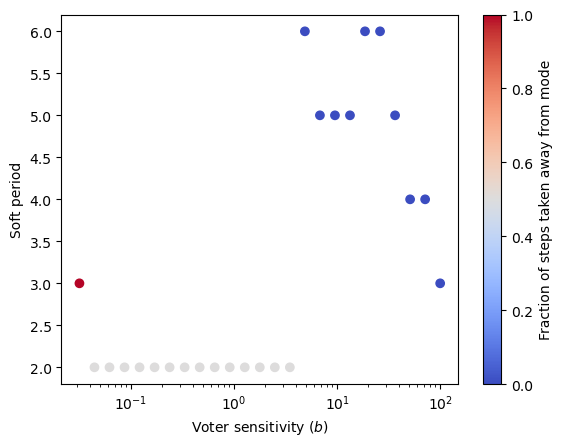

In [164]:
plt.scatter(bs,soft_periods,c=fracs_up,cmap='coolwarm')
plt.xscale('log')

cb = plt.colorbar()
cb.set_label('Fraction of steps taken away from mode')
plt.xlabel('Voter sensitivity ($b$)')
plt.ylabel('Soft period')


It seems like this distribution does support cycles, although not ones as long as in our simulation (6 elections at most). However, we do see the same trend, with sensitive voters yielding cycles that take steps towards the mode, and the insensitive voters yielding cycles that take steps away from the mode. So maybe the median-mode effect could be at play with respect to this real-world issue.

To make any firmer claims about the applicability of this theory to the real world would require looking at more than just one survey. It would be especially important to look at surveys that are used multiple times to get a sense of whether public opinion actually is shifting over time. This might imply an alternative explanation, unless the two parties dominate public discourse to the extent that everyone adjusts their answers to be in line with the shifting norms the parties set. For now though, I'll just leave you with a few other potential causes to consider:

* parties that care (differently) about winning vs policy
* preferences being slowly pushed by an information campaign until it goes too far beyond what's believable
* cycles in the distribution of power (see [cliodynamics](https://peterturchin.com/cliodynamics-is-not-cyclical-history/) )